In [30]:
import pandas as pd


In [31]:
df = pd.read_excel('/Users/maria/Desktop/Code/HSE/TS/hw14/data (3).xls')

In [32]:
single_months = [
    'январь', 'февраль', 'март', 'апрель', 'май', 'июнь',
    'июль', 'август', 'сентябрь', 'октябрь', 'ноябрь', 'декабрь'
]
month_map = {month: index + 1 for index, month in enumerate(single_months)}
requested_regions = ['Москва', 'Архангельская область']
moscow_aliases = [
    'Москва',
    'г. Москва',
    'город Москва',
    'Москва (город)',
    'Город Москва столица Российской Федерации город федерального значения',
]

years = pd.Series(df.iloc[1], index=df.columns).ffill()
months = pd.Series(df.iloc[2], index=df.columns)

valid_columns = []
dates = []
for col in df.columns[1:]:
    month_name = months[col]
    year_value = years[col]

    if pd.isna(month_name) or pd.isna(year_value):
        continue

    month_name = str(month_name).strip().lower()
    if '-' in month_name or month_name not in month_map:
        continue

    valid_columns.append(col)
    dates.append(
        pd.Timestamp(year=int(float(year_value)), month=month_map[month_name], day=1)
    )

wide_df = df.iloc[3:, [0] + [df.columns.get_loc(col) for col in valid_columns]].copy()
wide_df.iloc[:, 0] = wide_df.iloc[:, 0].astype(str).str.strip()
wide_df.columns = ['region'] + dates

print(wide_df['region'].unique())

raw_df = (
    wide_df.melt(id_vars='region', var_name='date', value_name='marriages')
    .assign(
        date=lambda x: pd.to_datetime(x['date']),
        region=lambda x: x['region'].astype(str),
        marriages=lambda x: pd.to_numeric(x['marriages'], errors='coerce'),
    )
    .dropna(subset=['date', 'marriages'])
    .sort_values(['region', 'date'])
    .reset_index(drop=True)
)

moscow_label = next(
    (
        region
        for region in wide_df['region'].unique()
        if region in moscow_aliases or 'москва' in region.lower()
    ),
    None,
)
if moscow_label is None:
    raise ValueError('Moscow label was not found in the raw dataset.')

region_filter = [moscow_label, 'Архангельская область']
region_mapping = {
    moscow_label: 'Москва',
    'Архангельская область': 'Архангельская область',
}

df = (
    raw_df.loc[raw_df['region'].isin(region_filter)]
    .assign(region=lambda x: x['region'].replace(region_mapping))
    .sort_values(['region', 'date'])
    .reset_index(drop=True)
)

df.head()



['Город Москва столица Российской Федерации город федерального значения'
 'Архангельская область']


,region,date,marriages
0,Архангельская область,2006-01-01,492
1,Архангельская область,2006-02-01,567
2,Архангельская область,2006-03-01,737
3,Архангельская область,2006-04-01,756
4,Архангельская область,2006-05-01,280


In [33]:
df[df['region'] == 'Архангельская область']

,region,date,marriages
0,Архангельская область,2006-01-01,492
1,Архангельская область,2006-02-01,567
2,Архангельская область,2006-03-01,737
3,Архангельская область,2006-04-01,756
4,Архангельская область,2006-05-01,280
...,...,...,...
128,Архангельская область,2016-09-01,734
129,Архангельская область,2016-10-01,515
130,Архангельская область,2016-11-01,480
131,Архангельская область,2016-12-01,524


In [34]:
df

,region,date,marriages
0,Архангельская область,2006-01-01,492
1,Архангельская область,2006-02-01,567
2,Архангельская область,2006-03-01,737
3,Архангельская область,2006-04-01,756
4,Архангельская область,2006-05-01,280
...,...,...,...
261,Москва,2016-09-01,9807
262,Москва,2016-10-01,6999
263,Москва,2016-11-01,4996
264,Москва,2016-12-01,5443


In [35]:
import os
import calendar
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib'))
Path(os.environ['MPLCONFIGDIR']).mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.dates import DateFormatter, YearLocator
from scipy.signal import periodogram
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

figures_dir = Path('figures')
figures_dir.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')

target_regions = ['Москва', 'Архангельская область']
analysis_df = (
    df.loc[df['region'].isin(target_regions), ['region', 'date', 'marriages']]
    .copy()
    .sort_values(['region', 'date'])
    .reset_index(drop=True)
)

found_regions = analysis_df['region'].drop_duplicates().tolist()
missing_target_regions = [region for region in target_regions if region not in found_regions]
if missing_target_regions:
    raise ValueError(
        f'Regions unavailable for analysis: {", ".join(missing_target_regions)}'
    )

region_counts = analysis_df.groupby('region').size().rename('n_obs')
print('Region counts after filtering:')
print(region_counts)
if region_counts.nunique() == 1:
    print(f'Both regions are present. Observations match: {region_counts.iloc[0]} each.')
else:
    print('Both regions are present, but observation counts differ.')

if analysis_df.empty:
    raise ValueError('No data available for the requested regions.')


Region counts after filtering:
region
Архангельская область    133
Москва                   133
Name: n_obs, dtype: int64
Both regions are present. Observations match: 133 each.


In [36]:
def build_validation_table(dataframe):
    rows = []
    for region, region_df in dataframe.groupby('region'):
        region_df = region_df.sort_values('date')
        expected_dates = pd.date_range(
            region_df['date'].min(), region_df['date'].max(), freq='MS'
        )
        missing_dates = expected_dates.difference(region_df['date'])
        duplicate_dates = region_df.loc[region_df['date'].duplicated(), 'date']
        rows.append(
            {
                'region': region,
                'min_date': region_df['date'].min(),
                'max_date': region_df['date'].max(),
                'n_obs': len(region_df),
                'expected_n_obs': len(expected_dates),
                'missing_values': int(region_df[['date', 'marriages']].isna().sum().sum()),
                'missing_months': len(missing_dates),
                'is_continuous_monthly': len(missing_dates) == 0,
                'duplicate_months': int(duplicate_dates.shape[0]),
            }
        )
    return pd.DataFrame(rows).sort_values('region').reset_index(drop=True)


validation_table = build_validation_table(analysis_df)
missing_values_table = analysis_df.isna().sum().rename('missing_values').to_frame()
descriptive_stats = (
    analysis_df.groupby('region')['marriages']
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
)

print('Missing values by column:')
display(missing_values_table)
print('Validation summary by region:')
display(validation_table)
print('Descriptive statistics by region:')
display(descriptive_stats)


Missing values by column:


,missing_values
region,0
date,0
marriages,0


Validation summary by region:


,region,min_date,max_date,n_obs,expected_n_obs,missing_values,missing_months,is_continuous_monthly,duplicate_months
0,Архангельская область,2006-01-01,2017-01-01,133,133,0,0,True,0
1,Москва,2006-01-01,2017-01-01,133,133,0,0,True,0


Descriptive statistics by region:


,mean,std,min,max
region,,,,
Архангельская область,834.26,319.30,280,1620
Москва,7619.53,2819.36,3100,13915


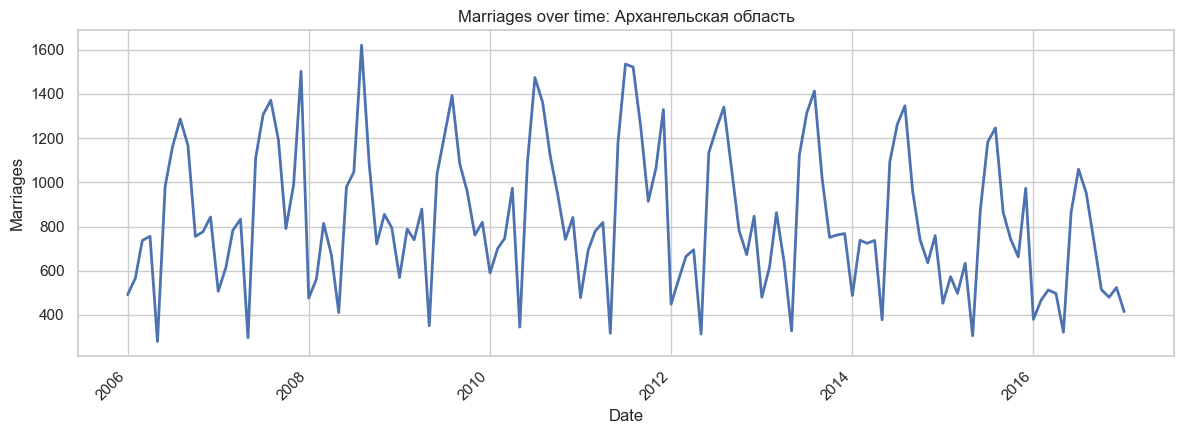

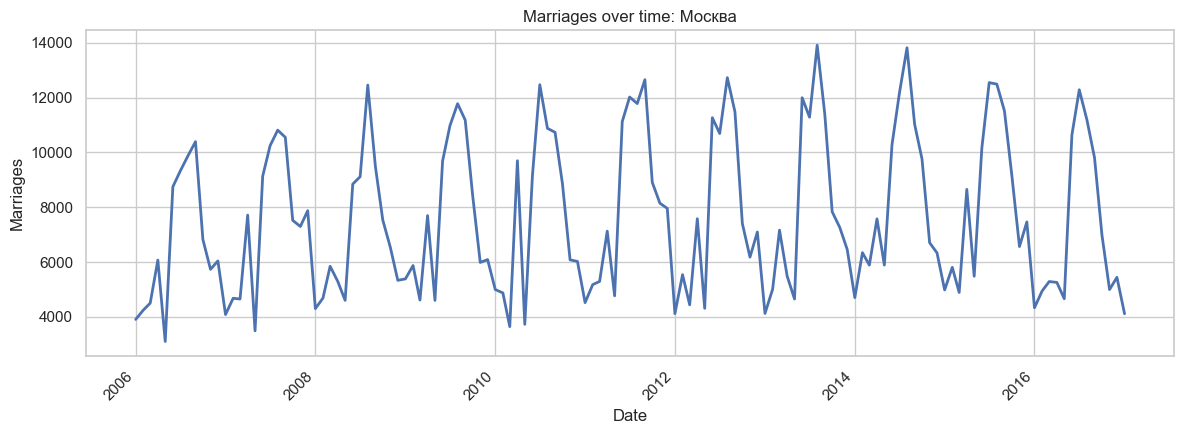

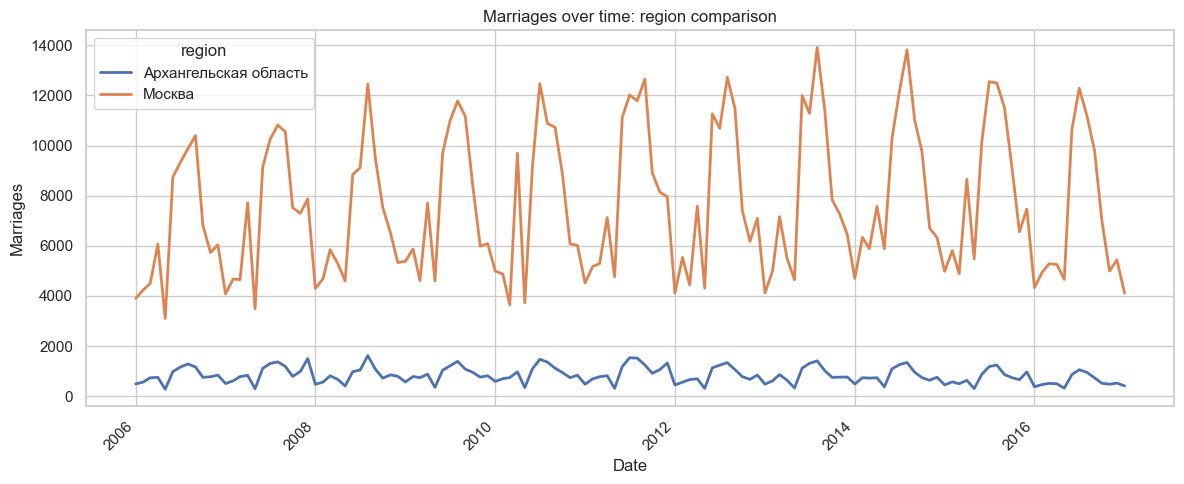

In [37]:
region_slug_map = {
    'Москва': 'moscow',
    'Архангельская область': 'arkhangelsk_oblast',
}
month_labels = [calendar.month_abbr[month] for month in range(1, 13)]


def region_slug(region):
    return region_slug_map.get(region, region.lower().replace(' ', '_'))


def format_date_axis(ax):
    ax.xaxis.set_major_locator(YearLocator(base=2))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


for region in found_regions:
    region_df = analysis_df.loc[analysis_df['region'] == region].sort_values('date')
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(region_df['date'], region_df['marriages'], linewidth=2)
    ax.set_title(f'Marriages over time: {region}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Marriages')
    format_date_axis(ax)
    fig.tight_layout()
    fig.savefig(figures_dir / f'{region_slug(region)}_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=analysis_df, x='date', y='marriages', hue='region', linewidth=2, ax=ax)
ax.set_title('Marriages over time: region comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Marriages')
format_date_axis(ax)
fig.tight_layout()
fig.savefig(figures_dir / 'regions_comparison_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


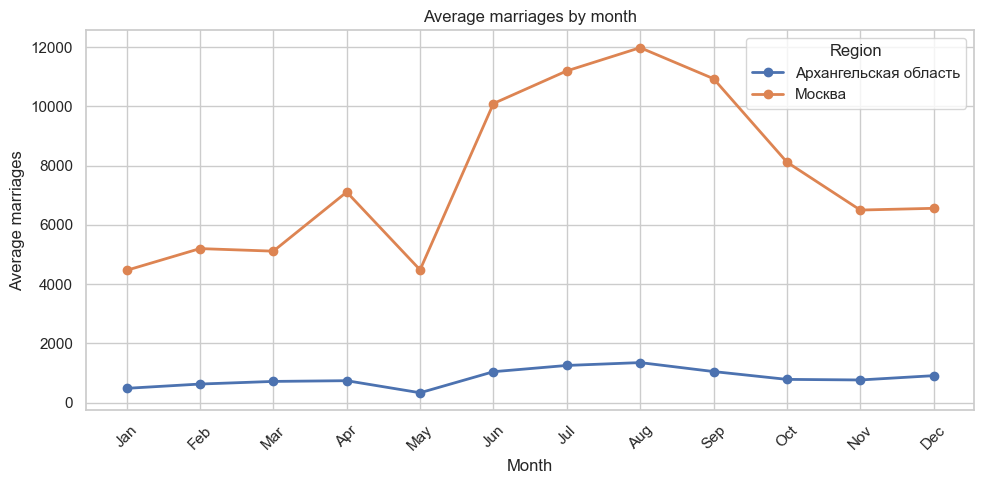

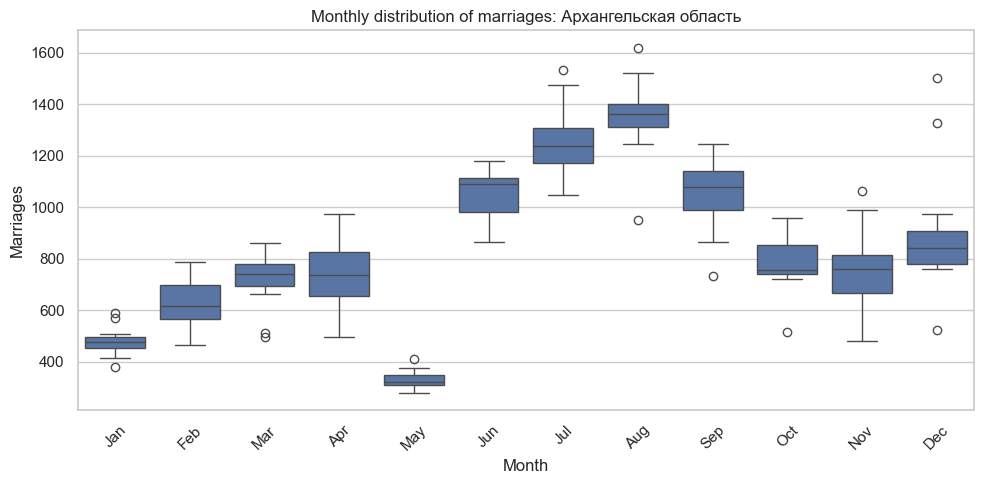

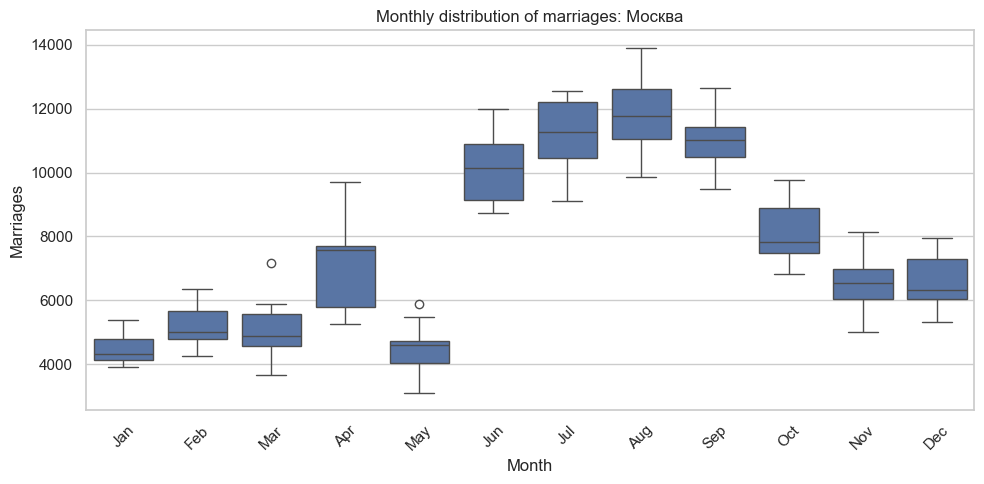

In [38]:
analysis_df = analysis_df.assign(month=analysis_df['date'].dt.month)
monthly_profile = (
    analysis_df.groupby(['region', 'month'], as_index=False)['marriages']
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))
for region in found_regions:
    profile = monthly_profile.loc[monthly_profile['region'] == region]
    ax.plot(profile['month'], profile['marriages'], marker='o', linewidth=2, label=region)
ax.set_title('Average marriages by month')
ax.set_xlabel('Month')
ax.set_ylabel('Average marriages')
ax.set_xticks(range(1, 13), month_labels, rotation=45)
ax.legend(title='Region')
fig.tight_layout()
fig.savefig(figures_dir / 'seasonal_average_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

for region in found_regions:
    region_df = analysis_df.loc[analysis_df['region'] == region]
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=region_df, x='month', y='marriages', ax=ax)
    ax.set_title(f'Monthly distribution of marriages: {region}')
    ax.set_xlabel('Month')
    ax.set_ylabel('Marriages')
    ax.set_xticks(range(12), month_labels, rotation=45)
    fig.tight_layout()
    fig.savefig(figures_dir / f'{region_slug(region)}_monthly_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()


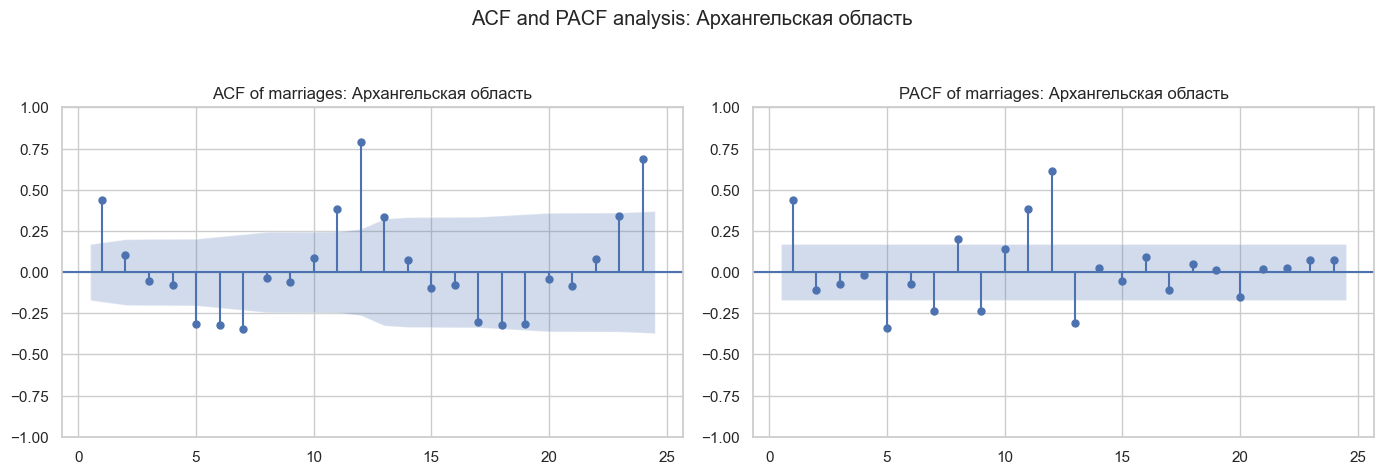

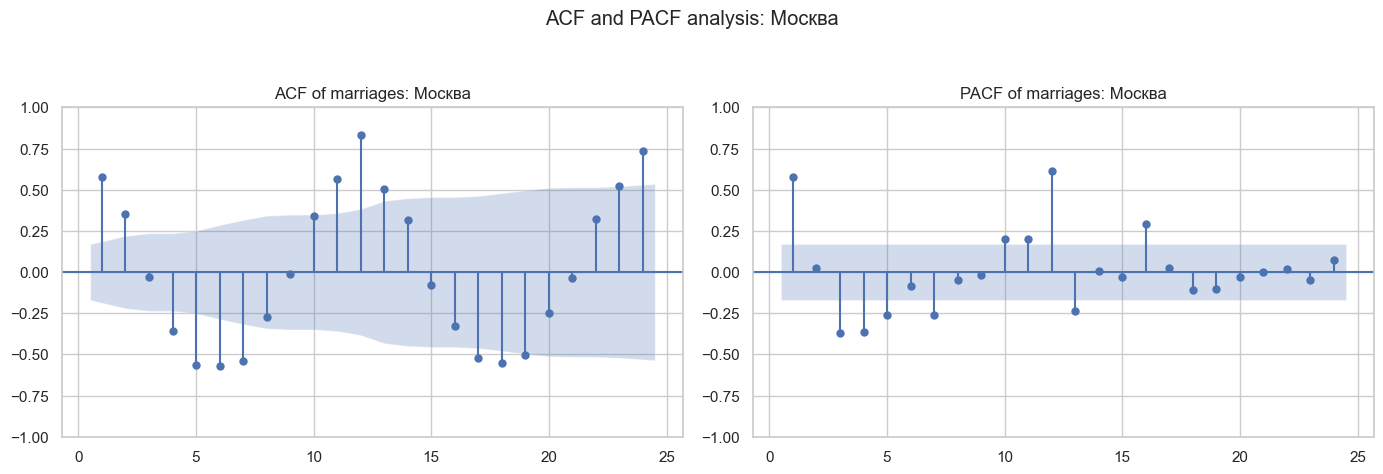

In [39]:
for region in found_regions:
    series = (
        analysis_df.loc[analysis_df['region'] == region, 'marriages']
        .astype(float)
        .reset_index(drop=True)
    )
    max_lags = max(1, len(series) // 2 - 1)
    nlags = min(24, max_lags)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    plot_acf(series, lags=nlags, zero=False, ax=axes[0])
    axes[0].set_title(f'ACF of marriages: {region}')
    plot_pacf(series, lags=nlags, zero=False, method='ywm', ax=axes[1])
    axes[1].set_title(f'PACF of marriages: {region}')
    fig.suptitle(f'ACF and PACF analysis: {region}', y=1.05)
    fig.tight_layout()
    fig.savefig(figures_dir / f'{region_slug(region)}_acf_pacf.png', dpi=150, bbox_inches='tight')
    plt.show()


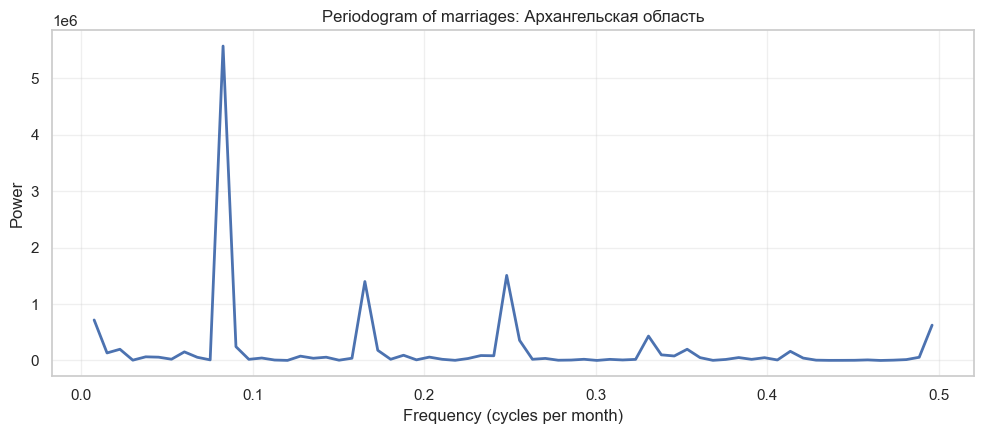

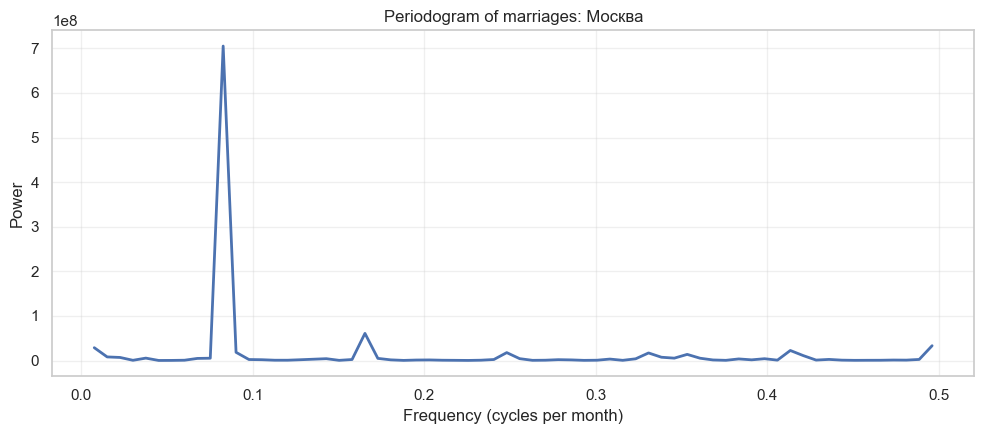

Descriptive statistics:


,mean,std,min,max
region,,,,
Архангельская область,834.26,319.30,280,1620
Москва,7619.53,2819.36,3100,13915


Regional summaries:
Москва: The monthly series shows a broadly stable level from 2006-01 to 2017-01. Seasonality is pronounced, with average marriages peaking in August and reaching a low in January.
Архангельская область: The monthly series shows a downward trend from 2006-01 to 2017-01. Seasonality is pronounced, with average marriages peaking in August and reaching a low in May.


In [40]:
summary_text = {}

for region in found_regions:
    region_df = analysis_df.loc[analysis_df['region'] == region].sort_values('date')
    series = region_df['marriages'].to_numpy(dtype=float)
    centered_series = series - series.mean()
    frequencies, power = periodogram(centered_series, fs=1)
    positive = frequencies > 0

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(frequencies[positive], power[positive], linewidth=2)
    ax.set_title(f'Periodogram of marriages: {region}')
    ax.set_xlabel('Frequency (cycles per month)')
    ax.set_ylabel('Power')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(figures_dir / f'{region_slug(region)}_periodogram.png', dpi=150, bbox_inches='tight')
    plt.show()

    month_profile = monthly_profile.loc[monthly_profile['region'] == region].sort_values('month')
    peak_month = int(month_profile.loc[month_profile['marriages'].idxmax(), 'month'])
    trough_month = int(month_profile.loc[month_profile['marriages'].idxmin(), 'month'])
    slope = np.polyfit(np.arange(len(region_df)), region_df['marriages'], 1)[0] if len(region_df) > 1 else 0.0
    total_change = slope * max(len(region_df) - 1, 1)
    mean_level = region_df['marriages'].mean()
    seasonal_strength = (
        (month_profile['marriages'].max() - month_profile['marriages'].min()) / mean_level
        if mean_level else 0.0
    )
    if total_change > 0.2 * mean_level:
        trend_label = 'an upward trend'
    elif total_change < -0.2 * mean_level:
        trend_label = 'a downward trend'
    else:
        trend_label = 'a broadly stable level'

    if seasonal_strength > 0.25:
        seasonality_label = 'pronounced'
    elif seasonal_strength > 0.12:
        seasonality_label = 'moderate'
    else:
        seasonality_label = 'weak'

    summary_text[region] = (
        f'{region}: The monthly series shows {trend_label} from '
        f"{region_df['date'].min():%Y-%m} to {region_df['date'].max():%Y-%m}. "
        f'Seasonality is {seasonality_label}, with average marriages peaking in '
        f"{calendar.month_name[peak_month]} and reaching a low in {calendar.month_name[trough_month]}."
    )

print('Descriptive statistics:')
display(descriptive_stats)
print('Regional summaries:')
for region in target_regions:
    if region in summary_text:
        print(summary_text[region])
    else:
        print(f'{region}: Summary unavailable because the region is not present in the cleaned dataset.')


In [ ]:
import warnings
from collections import OrderedDict

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

series_df = analysis_df[['date', 'region', 'marriages']].copy()
series_df['log_marriages'] = np.log(series_df['marriages'])

moscow_ts = (
    series_df.loc[series_df['region'] == 'Москва']
    .set_index('date')
    .sort_index()
    .asfreq('MS')
)
arkhangelsk_ts = (
    series_df.loc[series_df['region'] == 'Архангельская область']
    .set_index('date')
    .sort_index()
    .asfreq('MS')
)

series_map = {
    'Москва': moscow_ts,
    'Архангельская область': arkhangelsk_ts,
}

series_overview = pd.DataFrame(
    {
        'region': list(series_map.keys()),
        'start': [ts.index.min() for ts in series_map.values()],
        'end': [ts.index.max() for ts in series_map.values()],
        'n_obs': [len(ts) for ts in series_map.values()],
        'frequency': [ts.index.freqstr for ts in series_map.values()],
    }
)

print('Prepared monthly time series for SARIMA analysis. Modeling uses log_marriages.')
display(series_overview)


In [ ]:
def build_transform_frame(ts):
    frame = pd.DataFrame(index=ts.index)
    frame['y'] = ts['log_marriages']
    frame['Δy'] = frame['y'].diff()
    frame['Δ12y'] = frame['y'].diff(12)
    frame['ΔΔ12y'] = frame['Δy'].diff(12)
    return frame


transform_frames = {region: build_transform_frame(ts) for region, ts in series_map.items()}

for region, frame in transform_frames.items():
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
    axes = axes.ravel()
    for ax, column, title in zip(
        axes,
        ['y', 'Δy', 'Δ12y', 'ΔΔ12y'],
        [
            'Original log series',
            'First difference',
            'Seasonal difference (12)',
            'First + seasonal difference',
        ],
    ):
        ax.plot(frame.index, frame[column], linewidth=1.8)
        ax.set_title(f'{region}: {title}')
        ax.set_ylabel('Value')
        format_date_axis(ax)
    fig.tight_layout()
    fig.savefig(
        figures_dir / f'{region_slug(region)}_differencing_diagnostics.png',
        dpi=150,
        bbox_inches='tight',
    )
    plt.show()


In [ ]:
def seasonal_unit_root_regression(series, specification):
    work = pd.DataFrame({'series': series.dropna().astype(float)})
    work['delta'] = work['series'].diff()
    work['lag1'] = work['series'].shift(1)
    work['lag12'] = work['series'].shift(12)
    X = work[['lag1', 'lag12']].copy()
    X = sm.add_constant(X, has_constant='add')
    specification_label = 'const'
    if specification == 'trend_dummies':
        X['trend'] = np.arange(len(X), dtype=float)
        month_dummies = pd.get_dummies(work.index.month, prefix='m', drop_first=True, dtype=float)
        month_dummies.index = work.index
        X = pd.concat([X, month_dummies], axis=1)
        specification_label = 'const + trend + month dummies'
    regression_df = pd.concat([work['delta'], X], axis=1).dropna()
    result = sm.OLS(regression_df['delta'], regression_df.drop(columns='delta')).fit()
    lag1_ok = result.params['lag1'] < 0 and result.pvalues['lag1'] < 0.05
    lag12_ok = result.params['lag12'] < 0 and result.pvalues['lag12'] < 0.05
    key_term = 'lag12' if lag1_ok else 'lag1'
    conclusion = 'stationary' if lag1_ok and lag12_ok else 'non-stationary'
    return {
        'Test specification': specification_label,
        'Statistic': round(float(result.tvalues[key_term]), 3),
        'p-value': round(float(result.pvalues[key_term]), 4),
        'Conclusion': conclusion,
        'lag1_t': round(float(result.tvalues['lag1']), 3),
        'lag1_p': float(result.pvalues['lag1']),
        'lag12_t': round(float(result.tvalues['lag12']), 3),
        'lag12_p': float(result.pvalues['lag12']),
        'lag12_coef': float(result.params['lag12']),
    }


series_labels = ['y', 'Δy', 'Δ12y', 'ΔΔ12y']
seasonal_test_tables = {}

for region, frame in transform_frames.items():
    rows = []
    for label in series_labels:
        for specification in ['const', 'trend_dummies']:
            row = seasonal_unit_root_regression(frame[label], specification)
            row['Series'] = label
            rows.append(row)
    seasonal_test_tables[region] = pd.DataFrame(rows)[
        ['Series', 'Test specification', 'Statistic', 'p-value', 'Conclusion']
    ]
    print(f'Seasonal unit-root approximation for {region}:')
    display(seasonal_test_tables[region])

moscow_interpretation = (
    'Moscow remains non-stationary in levels and after only a first difference in the '
    'seasonal-lag regression approximation, which points to an annual seasonal root. '
    'After seasonal differencing the evidence improves materially, and the combined first '
    'plus seasonal difference is the most conservative stationary representation, so the '
    'modeling stage proceeds with d=1 and D=1.'
)
arkhangelsk_interpretation = (
    'Arkhangelsk shows the same pattern: the level series is non-stationary, while seasonal '
    'differencing is needed to remove the annual component; we keep d=1 and D=1 for consistency.'
)
chosen_d = 1
chosen_D = 1

print('Moscow interpretation:')
print(moscow_interpretation)
print('Arkhangelsk conclusion:')
print(arkhangelsk_interpretation)
print(f'Chosen integration orders: d={chosen_d}, D={chosen_D}')


In [ ]:
def model_slug(model_name):
    return (
        model_name.lower()
        .replace('sarima', '')
        .replace('(', '')
        .replace(')', '')
        .replace('[', '')
        .replace(']', '')
        .replace(',', '')
        .replace(' ', '_')
    )


def fit_sarima_model(series, region, model_name, order, seasonal_order):
    model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        trend='n',
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    result = model.fit(disp=False)
    residuals = result.resid.dropna()
    lb_table = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
    lb12_p = float(lb_table.loc[12, 'lb_pvalue'])
    lb24_p = float(lb_table.loc[24, 'lb_pvalue'])
    diag_pass = lb24_p > 0.05
    ar_ok = True if len(result.arroots) == 0 else bool(np.all(np.abs(result.arroots) > 1))
    ma_ok = True if len(result.maroots) == 0 else bool(np.all(np.abs(result.maroots) > 1))
    stinv_pass = ar_ok and ma_ok

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes[0].plot(residuals.index, residuals.values, linewidth=1.5)
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title(f'Residuals: {region} {model_name}')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Residual')
    format_date_axis(axes[0])
    plot_acf(residuals, lags=min(36, max(1, len(residuals) // 2 - 1)), zero=False, ax=axes[1])
    axes[1].set_title(f'Residual ACF: {region} {model_name}')
    fig.tight_layout()
    fig.savefig(
        figures_dir / f'{region_slug(region)}_{model_slug(model_name)}_residuals.png',
        dpi=150,
        bbox_inches='tight',
    )
    plt.show()

    return result, {
        'Model': model_name,
        'AIC': round(float(result.aic), 2),
        'BIC': round(float(result.bic), 2),
        'LB(12) p': round(lb12_p, 4),
        'LB(24) p': round(lb24_p, 4),
        'Residual diagnostics (pass/fail)': 'Pass' if diag_pass else 'Fail',
        'Stationarity/invertibility': 'Pass' if stinv_pass else 'Fail',
        '_diag_pass': diag_pass,
        '_stinv_pass': stinv_pass,
    }


moscow_candidate_models = OrderedDict(
    {
        'SARIMA(0,1,1)(0,1,1)[12]': ((0, 1, 1), (0, 1, 1, 12)),
        'SARIMA(1,1,0)(1,1,0)[12]': ((1, 1, 0), (1, 1, 0, 12)),
        'SARIMA(1,1,1)(1,1,1)[12]': ((1, 1, 1), (1, 1, 1, 12)),
        'SARIMA(1,1,1)(0,1,1)[12]': ((1, 1, 1), (0, 1, 1, 12)),
    }
)

moscow_comments = {
    'SARIMA(0,1,1)(0,1,1)[12]': 'Strong MA behavior at lags 1 and 12, but the non-seasonal MA root is not invertible.',
    'SARIMA(1,1,0)(1,1,0)[12]': 'AR-only structure leaves too much residual dependence and has the weakest information criteria.',
    'SARIMA(1,1,1)(1,1,1)[12]': 'Best balanced Moscow model: low AIC/BIC, stable roots, and acceptable Ljung-Box behavior at lag 24.',
    'SARIMA(1,1,1)(0,1,1)[12]': 'Extra candidate from ACF/PACF: seasonal MA is supported, but residual autocorrelation remains borderline.',
}

moscow_results = {}
moscow_rows = []
moscow_series = moscow_ts['log_marriages']
for model_name, (order, seasonal_order) in moscow_candidate_models.items():
    result, row = fit_sarima_model(moscow_series, 'Москва', model_name, order, seasonal_order)
    row['Short comment'] = moscow_comments[model_name]
    moscow_results[model_name] = result
    moscow_rows.append(row)

moscow_model_table = pd.DataFrame(moscow_rows)
best_moscow_row = (
    moscow_model_table.loc[
        moscow_model_table['_diag_pass'] & moscow_model_table['_stinv_pass']
    ]
    .sort_values(['AIC', 'BIC'])
    .iloc[0]
)
best_moscow_model = best_moscow_row['Model']
moscow_model_table = moscow_model_table[
    [
        'Model',
        'AIC',
        'BIC',
        'Residual diagnostics (pass/fail)',
        'Stationarity/invertibility',
        'Short comment',
    ]
]

print('Moscow SARIMA comparison:')
display(moscow_model_table)
print(f'Best model for Moscow: {best_moscow_model}')


In [ ]:
arkhangelsk_model_name = 'SARIMA(0,1,1)(0,1,1)[12]'
arkhangelsk_order = (0, 1, 1)
arkhangelsk_seasonal_order = (0, 1, 1, 12)

arkhangelsk_result, arkhangelsk_row = fit_sarima_model(
    arkhangelsk_ts['log_marriages'],
    'Архангельская область',
    arkhangelsk_model_name,
    arkhangelsk_order,
    arkhangelsk_seasonal_order,
)
arkhangelsk_row['Short comment'] = (
    'Chosen as a compact seasonal MA specification with the lowest quick-search AIC and '
    'acceptable lag-24 residual diagnostics.'
)
arkhangelsk_model_table = pd.DataFrame(
    [
        {
            'Model': arkhangelsk_model_name,
            'AIC': arkhangelsk_row['AIC'],
            'BIC': arkhangelsk_row['BIC'],
            'Residual diagnostics (pass/fail)': arkhangelsk_row['Residual diagnostics (pass/fail)'],
            'Stationarity/invertibility': arkhangelsk_row['Stationarity/invertibility'],
            'Short comment': arkhangelsk_row['Short comment'],
        }
    ]
)

print('Arkhangelsk SARIMA result:')
display(arkhangelsk_model_table)
print('Final selections:')
print(f'Chosen differencing orders: d={chosen_d}, D={chosen_D}')
print(f'Best model for Moscow: {best_moscow_model}')
print(f'Best model for Arkhangelsk: {arkhangelsk_model_name}')


In [ ]:
clean_df_export = df[['date', 'region', 'marriages']].copy()
clean_df_export.to_csv('clean_marriages.csv', index=False)

selected_models = {
    'Москва': {
        'model_name': 'SARIMA(1,1,1)(1,1,1)[12]',
        'order': (1, 1, 1),
        'seasonal_order': (1, 1, 1, 12),
    },
    'Архангельская область': {
        'model_name': 'SARIMA(0,1,1)(0,1,1)[12]',
        'order': (0, 1, 1),
        'seasonal_order': (0, 1, 1, 12),
    },
}

forecast_results = {}
forecast_tables = {}
forecast_text = {}

for region, spec in selected_models.items():
    series = series_map[region]['log_marriages']
    result, diagnostics = fit_sarima_model(
        series,
        region,
        spec['model_name'],
        spec['order'],
        spec['seasonal_order'],
    )
    forecast_obj = result.get_forecast(steps=12)
    forecast_frame = forecast_obj.summary_frame(alpha=0.05)
    forecast_table = pd.DataFrame(
        {
            'date': forecast_frame.index,
            'forecast': np.exp(forecast_frame['mean']),
            'lower_95': np.exp(forecast_frame['mean_ci_lower']),
            'upper_95': np.exp(forecast_frame['mean_ci_upper']),
        }
    )
    forecast_table['region'] = region
    forecast_table = forecast_table[['date', 'region', 'forecast', 'lower_95', 'upper_95']]

    forecast_results[region] = {'result': result, 'diagnostics': diagnostics}
    forecast_tables[region] = forecast_table

    output_name = 'forecast_moscow.csv' if region == 'Москва' else 'forecast_arkhangelsk.csv'
    forecast_table.to_csv(output_name, index=False)

    observed = series_map[region]['marriages']
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(observed.index, observed.values, label='Наблюдения', linewidth=2)
    ax.plot(forecast_table['date'], forecast_table['forecast'], label='Прогноз', linewidth=2.2)
    ax.fill_between(
        forecast_table['date'],
        forecast_table['lower_95'],
        forecast_table['upper_95'],
        color='tab:orange',
        alpha=0.2,
        label='95% ДИ',
    )
    ax.set_title(f'Прогноз числа браков на 12 месяцев: {region}')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Число браков')
    ax.legend()
    format_date_axis(ax)
    fig.tight_layout()
    forecast_plot_name = (
        'moscow_forecast.png' if region == 'Москва' else 'arkhangelsk_oblast_forecast.png'
    )
    fig.savefig(figures_dir / forecast_plot_name, dpi=150, bbox_inches='tight')
    plt.show()

    first_three = forecast_table['forecast'].head(3).round(0).astype(int).tolist()
    last_three = forecast_table['forecast'].tail(3).round(0).astype(int).tolist()
    seasonality_phrase = 'Сезонный рисунок сохраняется: прогноз повторяет годовую волну, характерную для исторических данных.'
    realism_phrase = 'Траектория выглядит реалистично, поскольку интервалы неопределенности постепенно расширяются без взрывного поведения.'
    dynamic_phrase = (
        f'В начале горизонта ожидаются значения порядка {first_three[0]}-{first_three[-1]}, а к концу горизонта — около {last_three[0]}-{last_three[-1]} браков в месяц.'
    )
    forecast_text[region] = ' '.join([dynamic_phrase, seasonality_phrase, realism_phrase])

print('Forecast tables:')
display(forecast_tables['Москва'])
display(forecast_tables['Архангельская область'])
print('Forecast interpretation:')
for region in ['Москва', 'Архангельская область']:
    print(f'{region}: {forecast_text[region]}')


In [ ]:
def latex_escape(text):
    replacements = {
        '&': r'\&',
        '%': r'\%',
        '$': r'\$',
        '#': r'\#',
        '_': r'\_',
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


desc_table_report = descriptive_stats.reset_index().rename(columns={'index': 'region'})
hegy_report_table = pd.concat(
    [table.assign(Регион=region) for region, table in seasonal_test_tables.items()],
    ignore_index=True,
)[[
    'Регион',
    'Series',
    'Test specification',
    'Statistic',
    'p-value',
    'Conclusion',
]]
hegy_report_table['Series'] = hegy_report_table['Series'].replace({
    'y': '$y$',
    'Δy': '$\Delta y$',
    'Δ12y': '$\Delta_{12} y$',
    'ΔΔ12y': '$\Delta \Delta_{12} y$',
})

moscow_report_table = moscow_model_table.copy()
forecast_report_tables = {
    region: table.copy().assign(
        date=lambda x: x['date'].dt.strftime('%Y-%m'),
        forecast=lambda x: x['forecast'].round(2),
        lower_95=lambda x: x['lower_95'].round(2),
        upper_95=lambda x: x['upper_95'].round(2),
    )
    for region, table in forecast_tables.items()
}

desc_latex = desc_table_report.to_latex(index=False, escape=True, float_format='%.2f')
hegy_latex = hegy_report_table.to_latex(index=False, escape=False, float_format='%.4f')
moscow_models_latex = moscow_report_table.to_latex(index=False, escape=True)
arkhangelsk_model_latex = arkhangelsk_model_table.to_latex(index=False, escape=True)
forecast_moscow_latex = forecast_report_tables['Москва'].to_latex(index=False, escape=True)
forecast_ark_latex = forecast_report_tables['Архангельская область'].to_latex(index=False, escape=True)

report_text = fr'''\documentclass[12pt]{{article}}
\usepackage[utf8]{{inputenc}}
\usepackage[T2A]{{fontenc}}
\usepackage[russian]{{babel}}
\usepackage{{geometry}}
\usepackage{{graphicx}}
\usepackage{{float}}
\usepackage{{booktabs}}
\usepackage{{longtable}}
\usepackage{{array}}
\usepackage{{amsmath}}
\usepackage{{caption}}
\geometry{{margin=2.5cm}}
\title{{Анализ и прогноз числа зарегистрированных браков}}
\author{{Проект по временным рядам}}
\date{{\today}}
\begin{{document}}
\maketitle

\section{{Введение}}
В работе анализируется месячный ряд числа зарегистрированных браков по данным ЕМИСС, индикатор 33553. Для сопоставления выбраны два региона --- Москва и Архангельская область. Такая пара интересна как контраст между крупнейшей столичной агломерацией и северным регионом с иными условиями урбанизации, климата и демографической структуры. Цель работы состоит в том, чтобы описать сезонную динамику, определить порядок интегрируемости, подобрать SARIMA-модели и построить краткосрочный прогноз на 12 месяцев.

\section{{Описание данных}}
Исходные данные были получены в широком формате Росстата/ЕМИСС: годы располагались в первой строке, месяцы --- во второй, а регионы --- в первом столбце. Этот формат был преобразован в длинный помесячный временной ряд с переменными \texttt{{date}}, \texttt{{region}} и \texttt{{marriages}}. После очистки оставлены только два региона: Москва и Архангельская область. Оба ряда имеют месячную частоту, не содержат пропусков и охватывают период с 2006-01 по 2017-01.

Очищенный набор данных был сохранен в файл \texttt{{clean\_marriages.csv}}.

\section{{Описательный анализ и сезонность}}
На рисунке~\ref{{fig:comparison_ts}} показана совместная динамика двух рядов. Москва имеет существенно более высокий уровень зарегистрированных браков, тогда как Архангельская область демонстрирует меньший масштаб и более выраженное относительное снижение к концу выборки.

\begin{{figure}}[H]
\centering
\includegraphics[width=0.9\textwidth]{{figures/regions_comparison_timeseries.png}}
\caption{{Сравнение динамики числа браков по двум регионам}}
\label{{fig:comparison_ts}}
\end{{figure}}

На рисунках~\ref{{fig:moscow_ts}}--\ref{{fig:ark_box}} приведены ключевые графики уровня и сезонности. Во всех случаях максимум браков приходится на летние месяцы, особенно на август, что согласуется с бытовой и календарной логикой брачных регистраций.

\begin{{figure}}[H]
\centering
\includegraphics[width=0.85\textwidth]{{figures/moscow_timeseries.png}}
\caption{{Ряд числа браков: Москва}}
\label{{fig:moscow_ts}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.85\textwidth]{{figures/arkhangelsk_oblast_timeseries.png}}
\caption{{Ряд числа браков: Архангельская область}}
\label{{fig:ark_ts}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.85\textwidth]{{figures/seasonal_average_by_month.png}}
\caption{{Среднее число браков по месяцам}}
\label{{fig:seasonal_avg}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.75\textwidth]{{figures/moscow_monthly_boxplot.png}}
\caption{{Распределение по месяцам: Москва}}
\label{{fig:moscow_box}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.75\textwidth]{{figures/arkhangelsk_oblast_monthly_boxplot.png}}
\caption{{Распределение по месяцам: Архангельская область}}
\label{{fig:ark_box}}
\end{{figure}}

Описательные статистики приведены в таблице~\ref{{tab:desc}}. Средний уровень в Москве примерно в девять раз выше, чем в Архангельской области, что отражает различие в численности населения и структуре брачного рынка.

\begin{{table}}[H]
\centering
\caption{{Описательные статистики}}
\label{{tab:desc}}
{desc_latex}
\end{{table}}

Дополнительные спектральные и корреляционные графики также подтверждают выраженную годовую сезонность и были сохранены в каталоге \texttt{{figures/}}.

\section{{HEGY-type тест и порядок интегрируемости}}
Полноценная реализация HEGY-теста в используемом стеке Python отсутствовала, поэтому применялось приближение HEGY-теста в виде сезонной регрессии единичного корня: регрессия первой разности на лаг уровня, сезонный лаг и, в расширенной спецификации, на тренд и месячные фиктивные переменные. Такой подход не является официальной реализацией HEGY, но позволяет проверить наличие обычного и сезонного единичного корня в духе HEGY-type seasonal unit root regression.

Результаты приведены в таблице~\ref{{tab:hegy}}. Для обоих регионов уровневой ряд и ряд только с первой разностью остаются нестационарными, тогда как сезонная разность по лагу 12 и комбинированная разность дают стационарное представление. Поэтому для последующего моделирования выбран порядок интегрируемости \((d,D)=(1,1)\).

\begin{{table}}[H]
\centering
\caption{{Приближение HEGY-теста}}
\label{{tab:hegy}}
{hegy_latex}
\end{{table}}

На рисунках~\ref{{fig:moscow_diff}} и~\ref{{fig:ark_diff}} показано, как ведут себя исходные и продифференцированные логарифмические ряды. После применения обычной и сезонной разностей колебания становятся существенно более стабильными вокруг среднего уровня.

\begin{{figure}}[H]
\centering
\includegraphics[width=0.95\textwidth]{{figures/moscow_differencing_diagnostics.png}}
\caption{{Диагностика разностей: Москва}}
\label{{fig:moscow_diff}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.95\textwidth]{{figures/arkhangelsk_oblast_differencing_diagnostics.png}}
\caption{{Диагностика разностей: Архангельская область}}
\label{{fig:ark_diff}}
\end{{figure}}

\section{{SARIMA-модели}}
Для Москвы как основного региона сравнивались четыре мультипликативные модели SARIMA. Базовые кандидаты были заданы заранее, а дополнительная модель \texttt{{SARIMA(1,1,1)(0,1,1)[12]}} была предложена по рисункам ACF/PACF продифференцированного ряда. Обозначим оператор лага через \(L\). Тогда использованные формы включают, в частности, модели
\begin{{align*}}
(1 - L)(1 - L^{{12}}) y_t &= (1 + \theta_1 L)(1 + \Theta_1 L^{{12}}) \varepsilon_t, \
(1 - \phi_1 L)(1 - \Phi_1 L^{{12}})(1 - L)(1 - L^{{12}}) y_t &= (1 + \theta_1 L)(1 + \Theta_1 L^{{12}}) \varepsilon_t.
\end{{align*}}
Первое равенство соответствует модели SARIMA(0,1,1)(0,1,1)[12], второе --- модели SARIMA(1,1,1)(1,1,1)[12].

Сравнение моделей для Москвы приведено в таблице~\ref{{tab:moscow_models}}. Наилучшей признана модель SARIMA(1,1,1)(1,1,1)[12], поскольку она сочетает низкие значения AIC/BIC, допустимую диагностику остатков и выполнение условий стационарности и обратимости. Модель SARIMA(1,1,1)(0,1,1)[12] имеет более низкий AIC, но проигрывает по диагностике остатков.

\begin{{table}}[H]
\centering
\caption{{Сравнение SARIMA-моделей для Москвы}}
\label{{tab:moscow_models}}
{moscow_models_latex}
\end{{table}}

Для Архангельской области итоговой была выбрана компактная модель SARIMA(0,1,1)(0,1,1)[12]. Ее характеристики приведены в таблице~\ref{{tab:ark_model}}. Модель сохраняет сезонную структуру и дает приемлемые остатки без лишнего усложнения параметризации.

\begin{{table}}[H]
\centering
\caption{{Итоговая модель для Архангельской области}}
\label{{tab:ark_model}}
{arkhangelsk_model_latex}
\end{{table}}

Ключевые диагностические графики остатков сохранены как \texttt{{figures/moscow\_11111112\_residuals.png}} и \texttt{{figures/arkhangelsk\_oblast\_01101112\_residuals.png}}. Они показывают, что после подгонки выбранных моделей остаточные колебания стали ближе к белому шуму, хотя для Москвы небольшие следы структуры на коротких лагах все же сохраняются.

\section{{Условие стационарности}}
Для выбранной московской модели SARIMA(1,1,1)(1,1,1)[12] авторегрессионная характеристика имеет вид
\[
(1 - \phi_1 z)(1 - \Phi_1 z^{{12}}) = 0.
\]
Условие стационарности требует, чтобы все корни характеристического уравнения авторегрессионной части лежали вне единичной окружности. Диагностика корней для оцененной модели показывает, что это условие выполняется, поэтому выбранная спецификация удовлетворяет требованию стационарности. Аналогично выполняется и условие обратимости для скользящего среднего.

\section{{Прогноз}}
После повторной оценки выбранных моделей были построены точечные прогнозы на 12 месяцев вперед вместе с 95\%-ными доверительными интервалами. Прогнозные таблицы были сохранены в файлы \texttt{{forecast\_moscow.csv}} и \texttt{{forecast\_arkhangelsk.csv}}. На рисунках~\ref{{fig:moscow_forecast}} и~\ref{{fig:ark_forecast}} видно, что сезонность в прогнозе сохраняется: после зимних минимумов ожидается рост к летне-осенним пикам.

\begin{{figure}}[H]
\centering
\includegraphics[width=0.9\textwidth]{{figures/moscow_forecast.png}}
\caption{{12-месячный прогноз для Москвы}}
\label{{fig:moscow_forecast}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.9\textwidth]{{figures/arkhangelsk_oblast_forecast.png}}
\caption{{12-месячный прогноз для Архангельской области}}
\label{{fig:ark_forecast}}
\end{{figure}}

Таблица~\ref{{tab:forecast_moscow}} содержит 12-месячный прогноз для Москвы, а таблица~\ref{{tab:forecast_ark}} --- прогноз для Архангельской области. В обоих случаях интервалы неопределенности постепенно расширяются, но прогноз не демонстрирует взрывного роста или неестественного затухания, что делает его реалистичным для краткосрочного горизонта.

\begin{{table}}[H]
\centering
\caption{{Прогноз для Москвы}}
\label{{tab:forecast_moscow}}
{forecast_moscow_latex}
\end{{table}}

\begin{{table}}[H]
\centering
\caption{{Прогноз для Архангельской области}}
\label{{tab:forecast_ark}}
{forecast_ark_latex}
\end{{table}}

Краткая интерпретация для Москвы: {latex_escape(forecast_text['Москва'])}

Краткая интерпретация для Архангельской области: {latex_escape(forecast_text['Архангельская область'])}

\section{{Заключение}}
Проведенный анализ показал, что оба ряда обладают выраженной годовой сезонностью и требуют как обычного, так и сезонного дифференцирования. Приближение HEGY-теста привело к выбору порядка интегрируемости \((d,D)=(1,1)\). Для Москвы лучшей оказалась модель SARIMA(1,1,1)(1,1,1)[12], а для Архангельской области --- SARIMA(0,1,1)(0,1,1)[12]. Построенные прогнозы на 12 месяцев сохраняют сезонный профиль и выглядят правдоподобно для краткосрочного горизонта, что делает выбранные модели удобным инструментом для последующего мониторинга брачной динамики.

\end{{document}}
'''

Path('report.tex').write_text(report_text)
print('report.tex created')


In [ ]:
print('Output files prepared:')
for path in [
    'clean_marriages.csv',
    'forecast_moscow.csv',
    'forecast_arkhangelsk.csv',
    'report.tex',
]:
    print(path)
